#**Project Plan: Smartphone Data Analysis**

In [161]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [162]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# EDA

In [163]:
smartphones=pd.read_csv('/content/drive/MyDrive/dataset/smartphone_cleaned_data.csv')

In [164]:
smartphones.head(1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.7,1440 x 3216,120,3,1,50.0,16.0,android,0


In [165]:
smartphones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand_name              980 non-null    object 
 1   model                   980 non-null    object 
 2   price (inr)             980 non-null    int64  
 3   rating                  980 non-null    float64
 4   has_5g                  980 non-null    bool   
 5   has_nfc                 980 non-null    bool   
 6   has_ir_blaster          980 non-null    bool   
 7   processor_name          960 non-null    object 
 8   processor_brand         956 non-null    object 
 9   num_cores               974 non-null    object 
 10  speed (ghz)             938 non-null    float64
 11  ram_capacity (gb)       980 non-null    float64
 12  rom_capacity (gb)       977 non-null    float64
 13  battery_capacity (mah)  980 non-null    float64
 14  fast_charging (w)       980 non-null    in

# Column Types
# **Numerical**-
price (inr)
  ,rating  ,speed (ghz)   ,ram_capacity (gb) , fast_charging (w)   ,battery_capacity (mah),rom_capacity (gb)  , screen_size (inches),refresh_rate (hz)  ,num_of_rear_cameras ,num_of_front_cameras,rear_camera (mp) ,front_camera (mp)

# **Categorical**
- has_5g,has_nfc,has_ir_blaster   

# **Others**:
brand_name, model, processor_name, processor_brand, num_cores, resolution (pixels), os, extended_memory

In [166]:
smartphones.isnull().sum()

,0
brand_name,0
model,0
price (inr),0
rating,0
has_5g,0
has_nfc,0
has_ir_blaster,0
processor_name,20
processor_brand,24
num_cores,6


In [167]:
smartphones.describe()

,price (inr),rating,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp)
count,980.000000,980.000000,938.000000,980.000000,977.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,975.000000
mean,32520.504082,78.258248,2.427217,7.192857,135.579324,4800.476531,36.048980,6.552092,92.256122,2.813265,1.025510,50.317347,16.584615
std,39531.812669,7.010599,0.464090,16.576395,86.235715,1016.870214,35.948034,0.312149,28.988052,0.778167,0.181814,33.001939,10.879627
min,3499.000000,60.000000,1.200000,1.000000,1.000000,1821.000000,-1.000000,3.540000,60.000000,1.000000,0.000000,2.000000,0.000000
25%,12999.000000,75.000000,2.050000,4.000000,64.000000,4500.000000,15.000000,6.500000,60.000000,2.000000,1.000000,24.000000,8.000000
50%,19994.500000,79.000000,2.300000,6.000000,128.000000,5000.000000,30.000000,6.580000,90.000000,3.000000,1.000000,50.000000,16.000000
75%,35491.500000,84.000000,2.840000,8.000000,128.000000,5000.000000,65.000000,6.670000,120.000000,3.000000,1.000000,64.000000,16.000000
max,650000.000000,89.000000,3.220000,512.000000,512.000000,22000.000000,240.000000,8.030000,240.000000,4.000000,2.000000,200.000000,60.000000


#### **Univariate Analysis**

In [168]:
smartphones.head(1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.7,1440 x 3216,120,3,1,50.0,16.0,android,0


# **Brand Name**

In [169]:
smartphones['brand_name'].value_counts()

,count
brand_name,
xiaomi,134
samsung,132
vivo,111
realme,97
oppo,88
motorola,52
apple,46
oneplus,42
poco,41


#1. What are the most dominant smartphone brands in the market based on model availability?


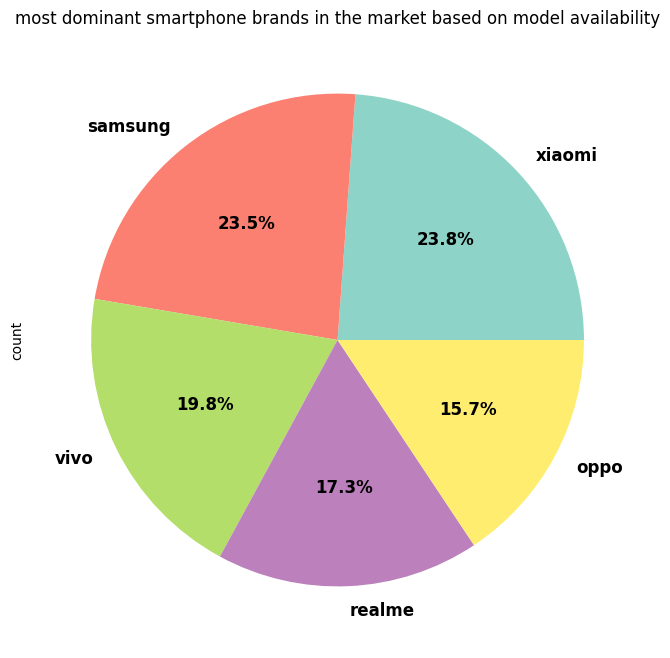

In [170]:
smartphones['brand_name'].value_counts().head(5).plot(kind='pie', colormap='Set3', autopct='%0.1f%%', figsize=(8,8),textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title("most dominant smartphone brands in the market based on model availability")

plt.show()

# **Price Distribution of Smartphones**


#1. What is the average price of smartphones?

In [171]:
smartphones['price (inr)'].isnull().sum()

np.int64(0)

In [172]:
smartphones['price (inr)'].describe()

,price (inr)
count,980.000000
mean,32520.504082
std,39531.812669
min,3499.000000
25%,12999.000000
50%,19994.500000
75%,35491.500000
max,650000.000000


**overall avg price**

In [173]:
smartphones['price (inr)'].mean()#it is not something relatable ?


np.float64(32520.504081632655)

In [174]:
smartphones['price (inr)'].median()

19994.5

**distribution is not normal it is skewed so outliers would be in the data as per price coloumn**

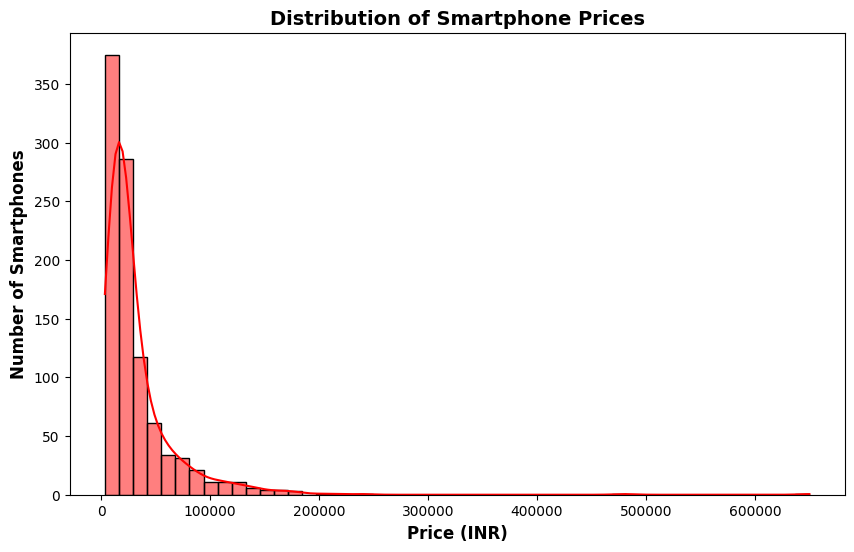

In [175]:
plt.figure(figsize=(10,6))
sns.histplot(smartphones['price (inr)'],bins=50,kde=True,color='red')
plt.title('Distribution of Smartphone Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (INR)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Smartphones', fontsize=12, fontweight='bold')

plt.show()

**Outliers**

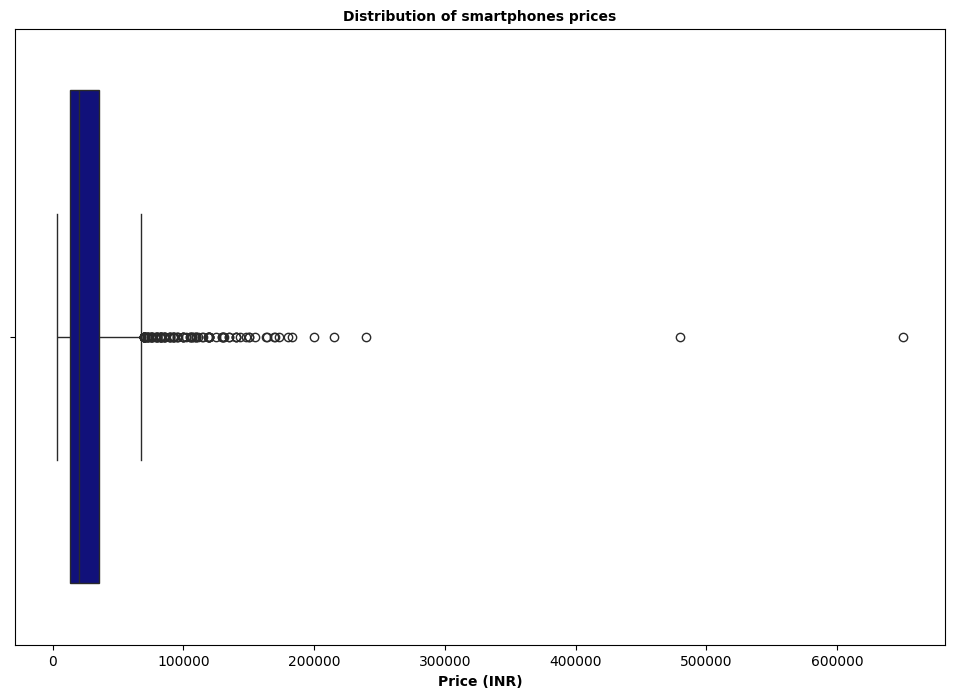

In [176]:
plt.figure(figsize=(12,8))
sns.boxplot(x=smartphones['price (inr)'],color='darkblue')
plt.title('Distribution of smartphones prices',fontsize=10,fontweight='bold')
plt.xlabel('Price (INR)',fontsize=10,fontweight='bold')
plt.show()

In [177]:
smartphones[smartphones['price (inr)']>200000]

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
427,vertu,Vertu Signature Touch,650000,62.000000,False,True,False,Snapdragon 801,snapdragon,Octa Core,1.50,2.0,64.0,2275.0,-1,4.70,1080 x 1920,60,1,1,13.0,2.0,android,0
478,huawei,Huawei Mate 50 RS Porsche Design,239999,81.000000,False,True,True,Snapdragon 8+ Gen1,snapdragon,Octa Core,3.20,512.0,NaN,4700.0,66,6.74,1212 x 2616,120,3,1,50.0,13.0,android,256 GB
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000,88.000000,False,True,False,Snapdragon 855,snapdragon,Octa Core,2.80,8.0,256.0,4000.0,27,6.39,1080 x 2340,60,3,1,48.0,20.0,android,0
951,huawei,Huawei Mate 30 RS Porsche Design,214990,78.258248,True,True,True,Kirin 990,kirin,Octa Core,2.86,12.0,512.0,4500.0,0,6.53,1176 x 2400,60,4,2,40.0,32.0,android,256 GB


**as per brands**

In [178]:
smartphones.groupby('brand_name').agg(
    avg_price=('price (inr)', 'mean'),
    model_count=('brand_name', 'count')
).sort_values(by='avg_price', ascending=False)

,avg_price,model_count
brand_name,,
vertu,650000.000000,1
royole,129999.000000,2
leitz,124990.000000,1
apple,95966.521739,46
huawei,80177.250000,16
asus,74709.428571,7
tesla,69999.000000,1
lg,63329.333333,3
sony,60570.666667,9


# 2. Skewness & Kurtosis – Check whether the price distribution is skewed toward high-end models

In [179]:
skewness=round(smartphones['price (inr)'].skew(),2)
skewness

np.float64(6.59)

In [180]:
round(kurtosis(smartphones['price (inr)']),2)

np.float64(78.78)


# Conclusion on Average Price Analysis
-  The average smartphone price is ₹32,520, influenced by ultra-premium models.

-  Xiaomi, Samsung, and Realme dominate the affordable segment, while Vertu and Porsche Design inflate the luxury range.

-  High prices often stem from brand prestige and luxury materials rather than superior specs.

-  Most consumers likely prefer value-for-money smartphones over luxury models.

-  There are outliers in price coloums -**luxury branding**
-  The smartphone price data is dominated by budget and mid-range models, but a few ultra-premium models (like Vertu, Porsche Design) inflate the overall price statistics. The high kurtosis confirms that these expensive outliers heavily impact the market analysis.


In [181]:
smartphones.head(1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.7,1440 x 3216,120,3,1,50.0,16.0,android,0


#  **rating analysis**

In [182]:
smartphones['rating'].isnull().sum()#previous done

np.int64(0)

<ipython-input-183-610906cf86b8>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating, x='rating', y='count', palette="viridis")


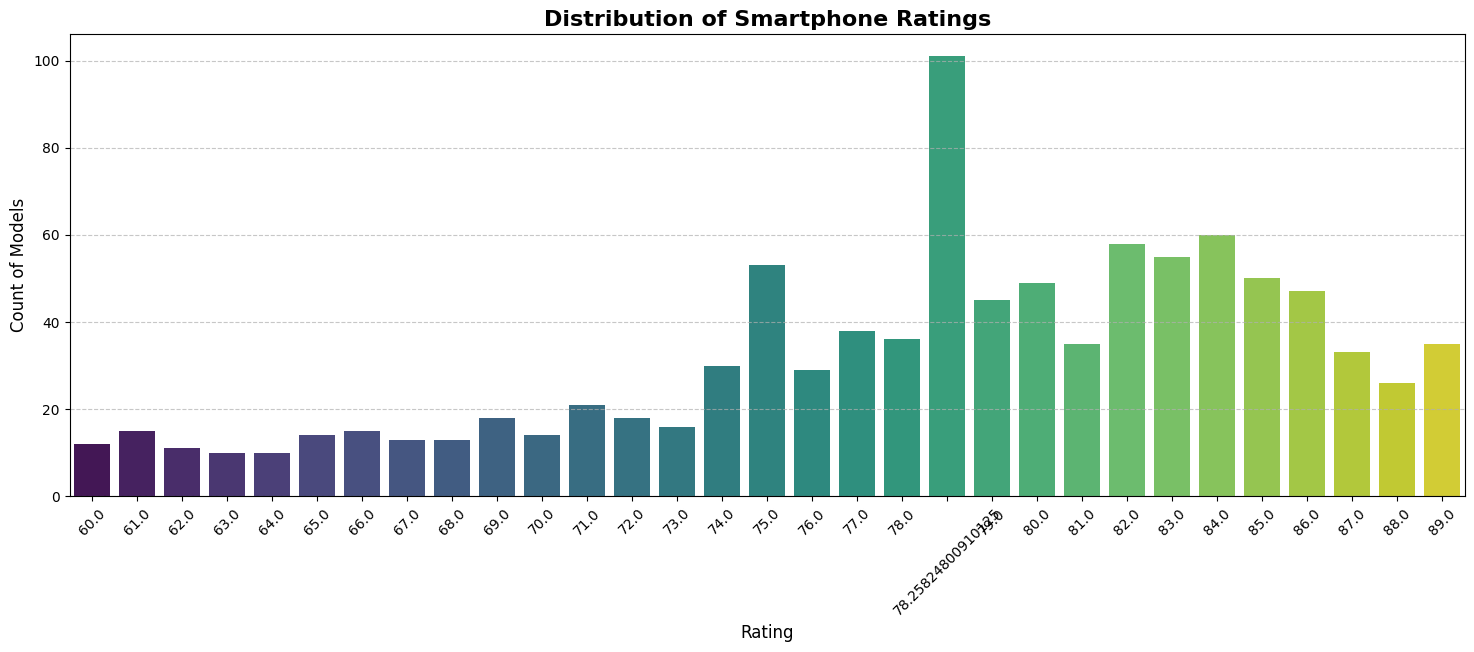

In [183]:
# Rating values counting
rating = smartphones['rating'].value_counts().reset_index()
rating.columns = ['rating', 'count']

# Plotting
plt.figure(figsize=(18,6))
sns.barplot(data=rating, x='rating', y='count', palette="viridis")

# Adding titles and labels
plt.title("Distribution of Smartphone Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Count of Models", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

<Axes: xlabel='rating', ylabel='Count'>

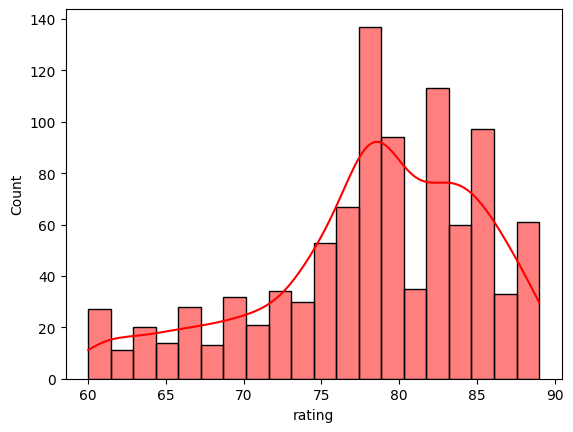

In [184]:
sns.histplot(smartphones['rating'].dropna(), bins=20, kde=True, color="red")

# Are there any significant outliers in smartphone ratings?

<Axes: xlabel='rating'>

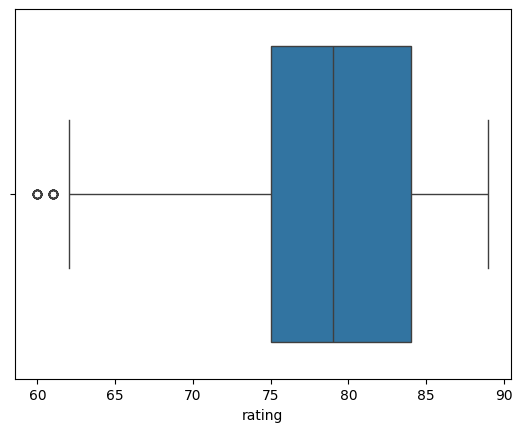

In [185]:
sns.boxplot(x=smartphones['rating'])

In [186]:
brand_rating = smartphones.groupby('brand_name')['rating'].mean().sort_values(ascending=False).reset_index()
brand_rating.columns = ['brand_name', 'avg_rating']
brand_rating

,brand_name,avg_rating
0,leitz,89.000000
1,lenovo,88.000000
2,sharp,88.000000
3,royole,87.000000
4,doogee,86.000000
5,asus,85.751178
6,zte,85.500000
7,nothing,85.200000
8,blu,85.000000
9,nubia,84.333333


<ipython-input-187-59d33f1b540b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_rating, x='brand_name', y='avg_rating', palette="viridis")


<Axes: xlabel='brand_name', ylabel='avg_rating'>

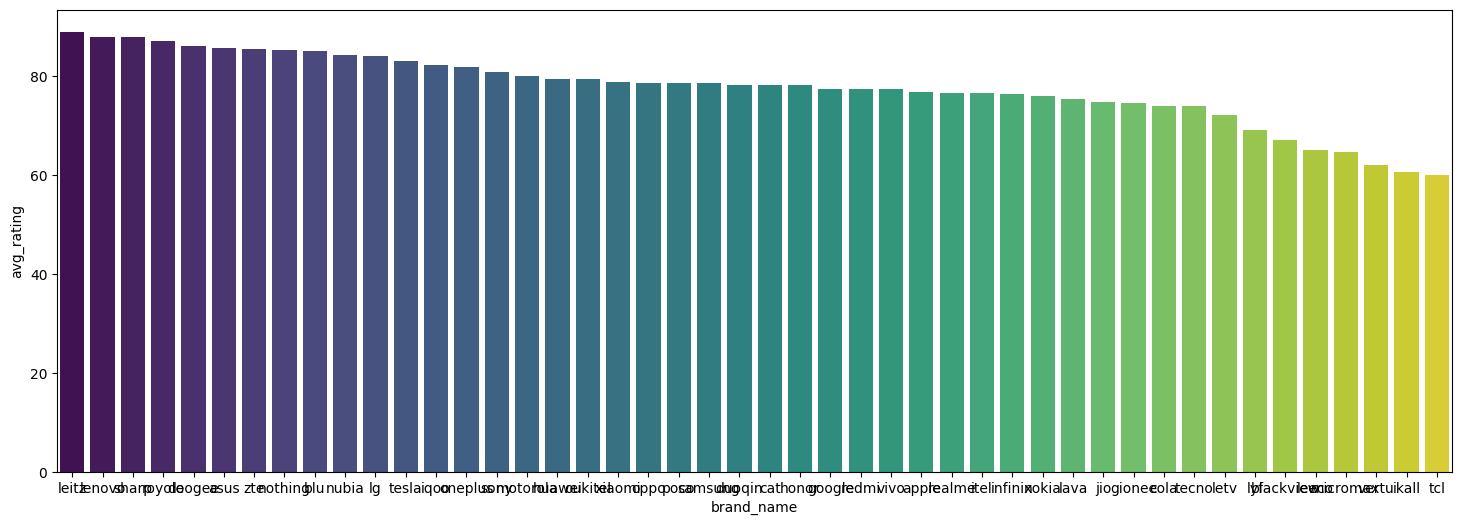

In [187]:
plt.figure(figsize=(18,6))
sns.barplot(data=brand_rating, x='brand_name', y='avg_rating', palette="viridis")

# Conclusion on Rating Analysis
-  Most smartphones have ratings between 75-85, showing overall user satisfaction.

-  A few outliers (below 65) indicate poorly received models, likely due to performance or user experience issues.

-  High ratings aren’t exclusive to premium models—some mid-range phones perform just as well.

-  Brands with consistently high ratings may offer better software, reliability, or customer trust.

In [188]:
smartphones.head(1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.7,1440 x 3216,120,3,1,50.0,16.0,android,0


# **has_5g  /has_Nfc /has_ir_blaster**

# What is the percentage distribution of 5G-enabled smartphones?

Text(0.5, 1.0, 'Distribution of 5G vs Non-5G Smartphones')

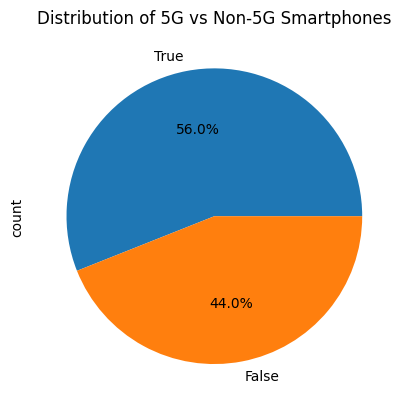

In [189]:
smartphones['has_5g'].value_counts().plot(kind='pie',autopct="%0.1f%%")
plt.title('Distribution of 5G vs Non-5G Smartphones')

#  Price Comparison: Do 5G phones cost more?//do nfc phones cost more // do ir blaster cost more

In [190]:
smartphones.groupby('has_5g')['price (inr)'].mean()

,price (inr)
has_5g,
False,18916.533643
True,43200.488160


NFC (Near Field Communication) is a wireless communication technology that allows devices to exchange data when they are close to each other (typically within a few centimeters).

 Common Uses of NFC in Smartphones:

 Contactless Payments (Google Pay, Apple Pay)

 Fast Data Transfer (Android Beam, NFC file sharing)

 Access Control & Tickets (Public transport, event passes)

Digital Keys (Smart locks, car unlocking)

,price (inr)
has_nfc,
False,17294.792164
True,55262.216285


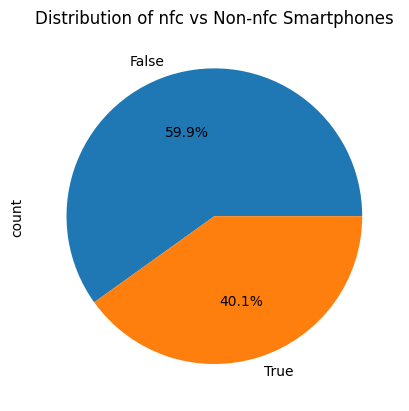

In [191]:
smartphones['has_nfc'].value_counts().plot(kind='pie',autopct="%0.1f%%")
plt.title('Distribution of nfc vs Non-nfc Smartphones')
smartphones.groupby('has_nfc')['price (inr)'].mean()

An IR Blaster (Infrared Blaster) is a feature that allows a smartphone to act as a universal remote control for TVs, air conditioners, set-top boxes, and other electronic devices that use infrared signals.

,price (inr)
has_ir_blaster,
False,32795.365408
True,31101.251572


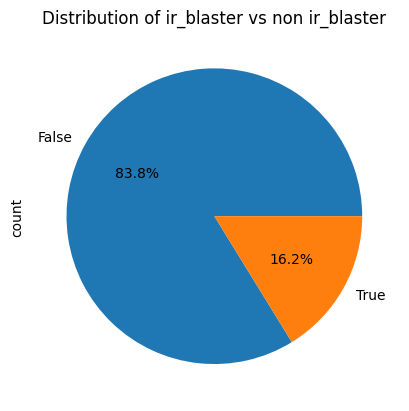

In [192]:
smartphones["has_ir_blaster"].value_counts().plot(kind='pie',autopct="%0.1f%%")
plt.title('Distribution of ir_blaster vs non ir_blaster')
smartphones.groupby("has_ir_blaster")["price (inr)"].mean()


In [193]:
smartphones[smartphones['has_ir_blaster']==True]['brand_name'].value_counts()

,count
brand_name,
xiaomi,109
poco,30
iqoo,6
huawei,6
vivo,4
redmi,2
honor,1
samsung,1


# conclusion
-  5G Adoption: Only 56% of smartphones in the dataset support 5G, indicating that 5G models  dominate the market.
- Price Difference: 5G smartphones are significantly more expensive, with an average price of ₹43,200, compared to ₹18,916 for non-5G models.
- NFC-enabled smartphones are significantly more expensive, with an average price of ₹55,262, compared to ₹17,294 for non-NFC models.
-  Only 16.2% of smartphones have an IR Blaster, indicating that it's not a widely included feature.
-  Xiaomi, Poco, iQOO, Huawei, and Vivo are all Chinese brands, and they dominate the IR Blaster category. This suggests that Chinese smartphone manufacturers are more likely to include IR Blasters in their devices

In [194]:
smartphones.head(1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.7,1440 x 3216,120,3,1,50.0,16.0,android,0


# processor speed/battery_capacity

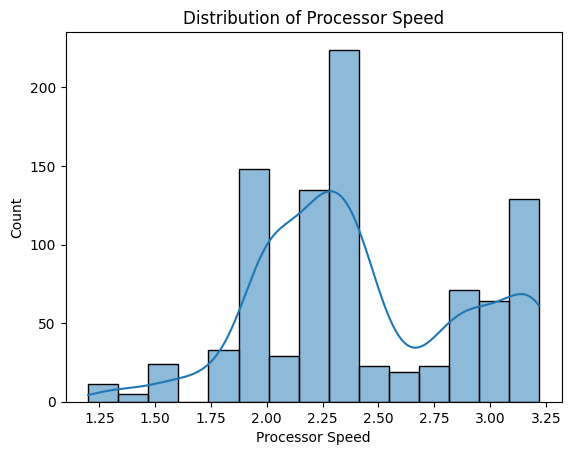

In [195]:
sns.histplot(smartphones['speed (ghz)'], bins=15, kde=True)
plt.title('Distribution of Processor Speed')
plt.xlabel('Processor Speed')
plt.ylabel('Count')
plt.show()

In [196]:
brand_speed = smartphones.groupby('brand_name')['speed (ghz)'].mean().sort_values(ascending=False)
brand_speed

,speed (ghz)
brand_name,
asus,3.157143
nubia,3.116667
zte,3.100000
apple,3.074375
leitz,3.000000
lenovo,2.920000
royole,2.840000
sharp,2.840000
iqoo,2.738065


Text(0.5, 1.0, 'Distribution of Battery Capacity in Smartphones')

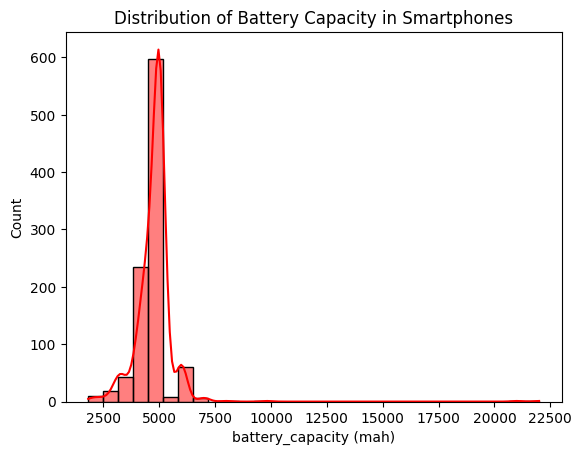

In [197]:
sns.histplot(smartphones['battery_capacity (mah)'], bins=30, kde=True, color="red")
plt.title("Distribution of Battery Capacity in Smartphones")

In [198]:
brand_battery = smartphones.groupby('brand_name').agg(battery_capacity_as_per_brand=('battery_capacity (mah)','mean'),battery_capacity_as_per_price=('price (inr)','mean')).sort_values(by='battery_capacity_as_per_price',ascending=False)
brand_battery

,battery_capacity_as_per_brand,battery_capacity_as_per_price
brand_name,,
vertu,2275.000000,650000.000000
royole,3905.000000,129999.000000
leitz,5000.000000,124990.000000
apple,3467.869565,95966.521739
huawei,4360.000000,80177.250000
asus,5757.142857,74709.428571
tesla,5000.000000,69999.000000
lg,4433.333333,63329.333333
sony,4400.000000,60570.666667


#conclusion
- Asus Leads in Processor Speed
- Brands like Asus, Nubia, and ZTE dominate , making them ideal for gaming and heavy multitasking.
-  Luxury brands like Vertu have the lowest average battery capacity (2275mAh) but the highest price (₹650,000).
- Apple also has a lower battery capacity (~3467mAh) compared to competitors, yet it remains a premium brand
- Chinese Brands Offer Bigger Batteries at Lower Prices
Huawei, ZTE, and Xiaomi have larger battery capacities compared to premium brands like Apple and Google.
- battery capacity is not always directly proportional to price,

# ram capacity/internal memory

In [199]:
smartphones['ram_capacity (gb)'].value_counts()

,count
ram_capacity (gb),
8.0,339
6.0,234
4.0,215
12.0,85
3.0,54
2.0,32
16.0,9
1.0,7
18.0,2


Text(0.5, 1.0, 'Distribution of RAM Capacity in Smartphones')

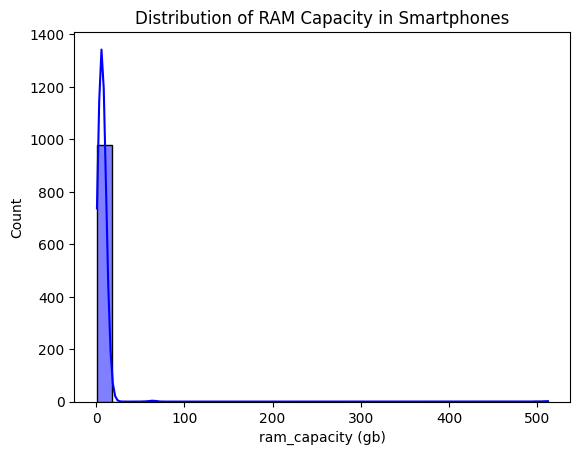

In [200]:
sns.histplot(smartphones['ram_capacity (gb)'], bins=30, kde=True, color="blue")
plt.title("Distribution of RAM Capacity in Smartphones")

In [201]:
smartphones['rom_capacity (gb)'].value_counts()

,count
rom_capacity (gb),
128.0,523
64.0,191
256.0,157
32.0,67
512.0,21
16.0,12
1.0,5
8.0,1


Text(0.5, 1.0, 'Distribution of ROM Capacity in Smartphones')

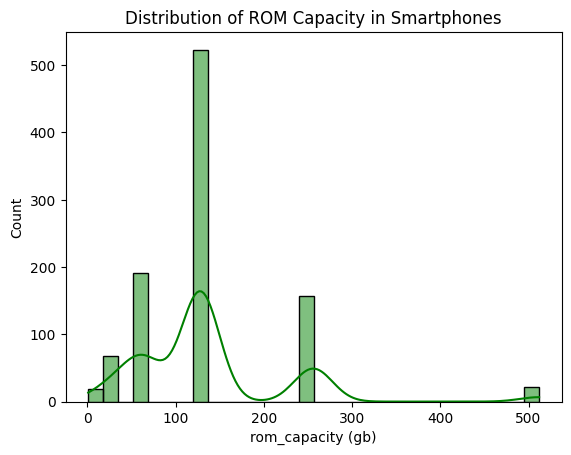

In [202]:
sns.histplot(smartphones['rom_capacity (gb)'], bins=30, kde=True, color="green")
plt.title("Distribution of ROM Capacity in Smartphones")

<Axes: xlabel='storage(gb)', ylabel='count'>

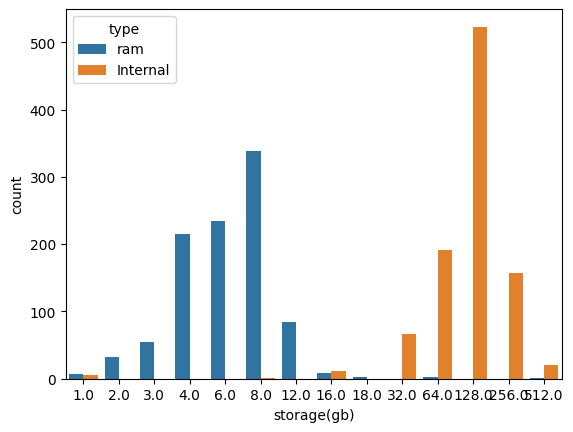

In [203]:
ram=smartphones['ram_capacity (gb)'].value_counts().reset_index()
ram.columns=['storage(gb)','count']
ram['type']='ram'
rom=smartphones['rom_capacity (gb)'].value_counts() .reset_index()
rom.columns=['storage(gb)','count']
rom['type']='Internal'
storage=pd.concat([ram,rom],axis=0)
sns.barplot(data=storage,x='storage(gb)',y='count',hue='type')

In [204]:
storage.groupby('type')['count'].sum()

,count
type,
Internal,977
ram,980


In [205]:
brand_memory = smartphones.groupby('brand_name').agg(
    avg_ram=('ram_capacity (gb)', 'mean'),
    avg_rom=('rom_capacity (gb)', 'mean'),
    avg_price=('price (inr)', 'mean')
).sort_values(by='avg_price', ascending=False)

print(brand_memory)

              avg_ram     avg_rom      avg_price
brand_name                                      
vertu        2.000000   64.000000  650000.000000
royole       8.000000  128.000000  129999.000000
leitz       12.000000  256.000000  124990.000000
apple        7.891304  179.727273   95966.521739
huawei      39.250000  230.400000   80177.250000
asus        13.714286  292.571429   74709.428571
tesla       16.000000  512.000000   69999.000000
lg           7.333333  128.000000   63329.333333
sony         7.777778  227.555556   60570.666667
sharp       12.000000  256.000000   59990.000000
lenovo      14.000000  384.000000   53494.500000
nubia        9.333333  170.666667   49827.833333
google       8.000000  137.142857   44332.571429
zte          7.000000  128.000000   40994.500000
samsung      6.537879  129.340909   36843.030303
oneplus      8.238095  156.952381   35858.571429
nothing      8.400000  179.200000   31195.400000
doogee      10.000000  192.000000   30499.000000
iqoo         8.06250

# conclusion
- Most smartphones have RAM ≤ 12GB and ROM between 64GB-256GB.

- Premium brands (Asus, Tesla, Huawei, Apple) offer higher RAM & ROM, aligning with higher prices.

- Budget brands (Itel, Lyf, Jio, Micromax) have lower RAM & ROM to keep costs low.

- Luxury brands (Vertu, Royole) have high prices but don’t necessarily offer higher memory.

- Higher RAM & ROM generally correlate with higher smartphone prices.

# os

<Axes: ylabel='count'>

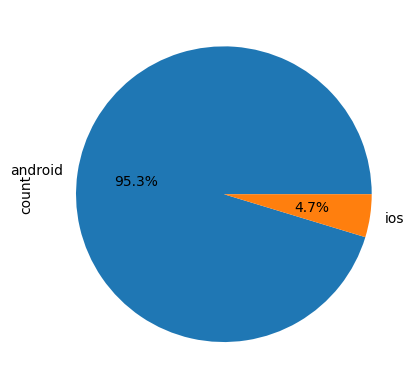

In [206]:
smartphones['os'].value_counts().plot(kind='pie',autopct='%1.1f%%')

# conclusion
- Majority of smartphones run on Android- dominated

# Rear & Front Camera Distribution

Text(0.5, 1.0, 'Distribution of Rear Camera ')

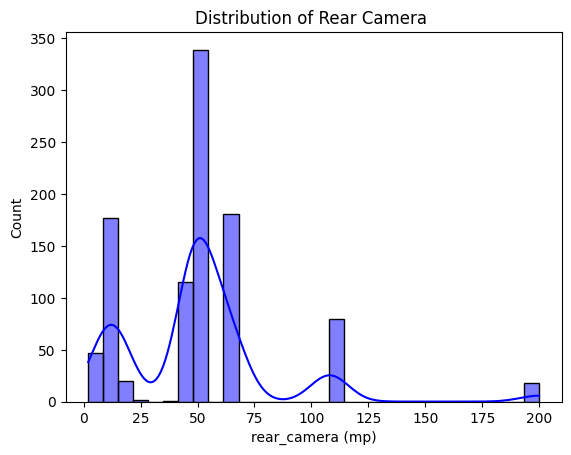

In [207]:
sns.histplot(smartphones['rear_camera (mp)'], bins=30, kde=True, color='blue')
plt.title("Distribution of Rear Camera ")

Text(0.5, 1.0, 'Distribution of Front Camera (MP)')

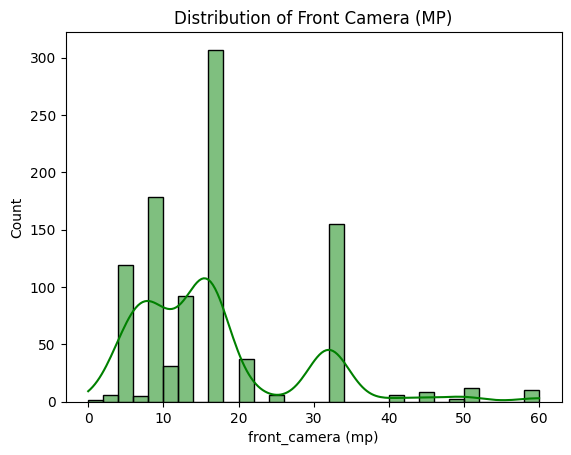

In [208]:

sns.histplot(smartphones['front_camera (mp)'], bins=30, kde=True, color='green')
plt.title("Distribution of Front Camera (MP)")

In [209]:
 brand_camera = smartphones.groupby('brand_name').agg(
        avg_rear_camera=('rear_camera (mp)', 'mean'),
        avg_front_camera=('front_camera (mp)', 'mean'),).sort_values(by='avg_rear_camera', ascending=False).reset_index()
brand_camera

,brand_name,avg_rear_camera,avg_front_camera
0,doogee,108.000000,32.000000
1,redmi,88.666667,12.333333
2,nokia,79.769231,14.692308
3,motorola,67.230769,24.019231
4,honor,66.692308,19.153846
5,xiaomi,65.298507,15.526316
6,royole,64.000000,32.000000
7,lenovo,64.000000,18.000000
8,nubia,59.333333,13.333333
9,infinix,59.000000,13.896552


In [210]:
brand_camera_melted = brand_camera.melt(id_vars='brand_name', value_vars=['avg_rear_camera', 'avg_front_camera'],
                                        var_name='Camera Type', value_name='Average MP')
brand_camera_melted

,brand_name,Camera Type,Average MP
0,doogee,avg_rear_camera,108.000000
1,redmi,avg_rear_camera,88.666667
2,nokia,avg_rear_camera,79.769231
3,motorola,avg_rear_camera,67.230769
4,honor,avg_rear_camera,66.692308
5,xiaomi,avg_rear_camera,65.298507
6,royole,avg_rear_camera,64.000000
7,lenovo,avg_rear_camera,64.000000
8,nubia,avg_rear_camera,59.333333
9,infinix,avg_rear_camera,59.000000


<Axes: xlabel='brand_name', ylabel='Average MP'>

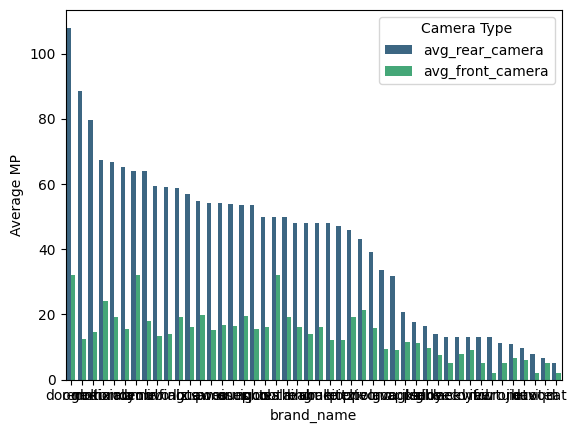

In [211]:
sns.barplot(data=brand_camera_melted, x='brand_name', y='Average MP', hue='Camera Type', palette='viridis')

# conclusion
- High Megapixels ≠ Best Camera – Brands like Apple, Google, and Sony have lower MP but deliver top-tier camera performance due to advanced image processing and software optimization.
- Chinese Brands Dominate High MP Counts – Doogee (108MP), Redmi (88MP), and Nokia (79MP)
-  Megapixel count alone does not define camera quality—software processing, sensor size, and optimizations play a crucial role!

#**Bivariate Analysis**
output coloumn=price vs different coloumn

In [212]:
smartphones.head(1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.7,1440 x 3216,120,3,1,50.0,16.0,android,0


#Find the average price per brand where count of model >10

In [213]:
temp_df=smartphones.groupby('brand_name').count()['model']

temp_df

,model
brand_name,
apple,46
asus,7
blackview,1
blu,1
cat,1
cola,1
doogee,2
duoqin,1
gionee,3


In [214]:
x=temp_df[temp_df>10]

In [215]:
temp_df=smartphones[smartphones['brand_name'].isin(x.index)]

In [216]:
temp_df=temp_df.groupby('brand_name').agg(avg_price=('price (inr)', 'mean')).sort_values(by='avg_price', ascending=False)
temp_df.reset_index(inplace=True)
temp_df

,brand_name,avg_price
0,apple,95966.521739
1,huawei,80177.250000
2,google,44332.571429
3,samsung,36843.030303
4,oneplus,35858.571429
5,iqoo,30301.875000
6,honor,30301.846154
7,oppo,29650.034091
8,xiaomi,27961.111940
9,vivo,26782.387387


<ipython-input-217-b96a9c40e5d6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=temp_df, x='brand_name', y='avg_price', palette="viridis", alpha=0.8)


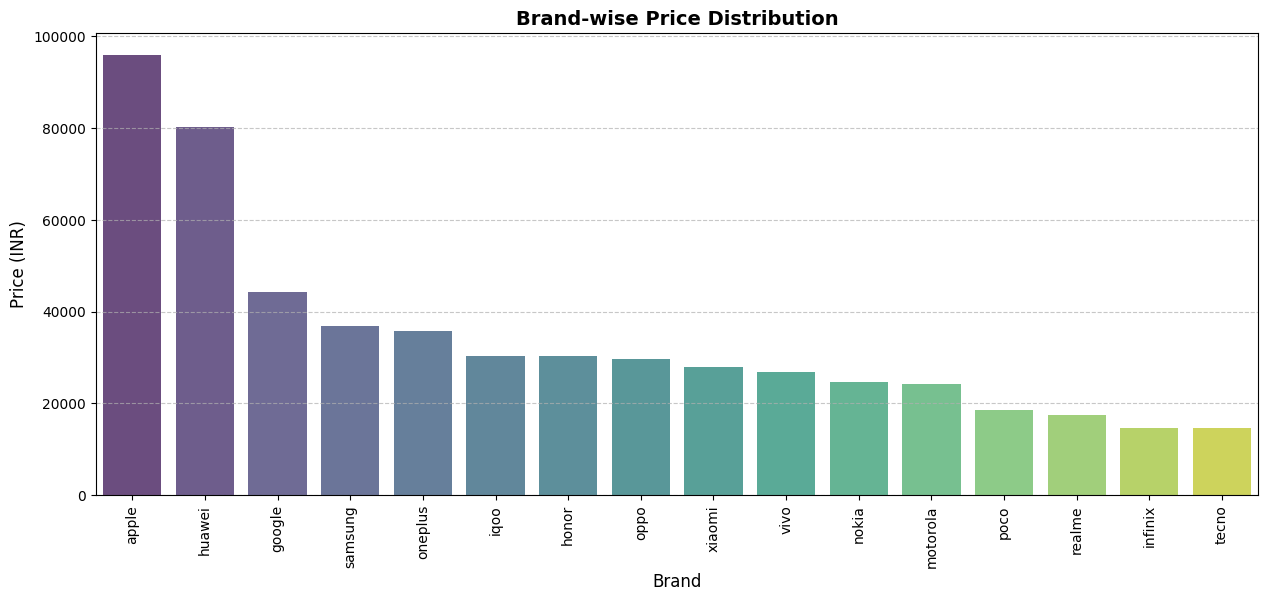

In [217]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=temp_df, x='brand_name', y='avg_price', palette="viridis", alpha=0.8)
plt.xticks(rotation=90)
plt.title("Brand-wise Price Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Price (INR)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)



# Conclusion
- Apple & Huawei lead the premium segment with prices around ₹80K-₹95K.

- Samsung, Google, OnePlus, and Xiaomi cater to both flagship and mid-range buyers (₹25K-₹45K).

- Poco, Realme, Infinix, and Tecno dominate the budget segment (~₹10K-₹18K).

- Xiaomi offers flagship-like features at mid-range prices, making it a strong value-for-money brand.

#price vs rating

In [218]:
correlation=smartphones[['price (inr)', 'rating']].corr()

<Axes: >

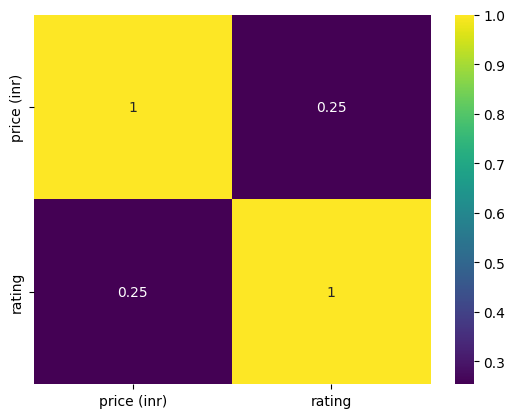

In [219]:
sns.heatmap(correlation,annot=True,cmap='viridis')

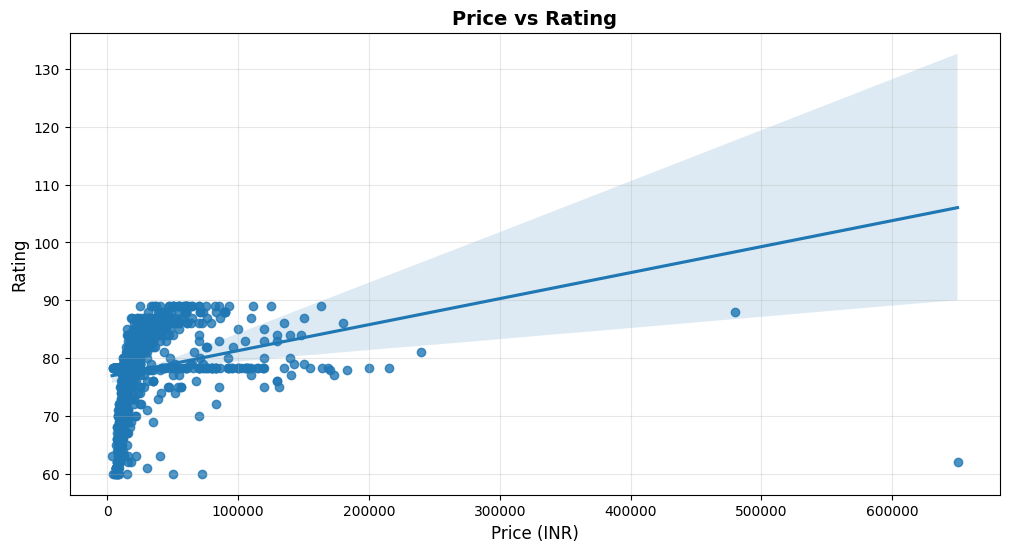

In [220]:
plt.figure(figsize=(12, 6))
sns.regplot(data=smartphones, x='price (inr)', y='rating')
plt.title("Price vs Rating", fontsize=14, fontweight='bold')
plt.xlabel("Price (INR)", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

#conclusion
- Higher-priced phones generally have better ratings, but the relationship is weak.
- Most phones, regardless of price, have similar ratings (around 80-90).
- Some expensive phones still receive low ratings, meaning price doesn’t always guarantee quality.

# price vs has_5g

<ipython-input-221-00be451e5f16>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smartphones, x='has_5g', y='price (inr)', palette="viridis",estimator=np.median)


Text(0.5, 1.0, 'Price vs 5G Support')

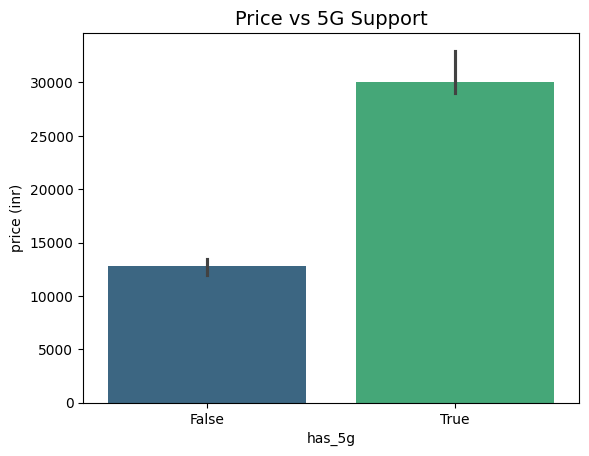

In [221]:
sns.barplot(data=smartphones, x='has_5g', y='price (inr)', palette="viridis",estimator=np.median)
plt.title("Price vs 5G Support", fontsize=14)

In [222]:
temp_df=smartphones.groupby(['has_5g', 'brand_name'])['price (inr)'].mean().reset_index()
temp_df

,has_5g,brand_name,price (inr)
0,False,apple,60417.444444
1,False,cat,14999.000000
2,False,cola,14999.000000
3,False,doogee,14999.000000
4,False,duoqin,9990.000000
5,False,gionee,6896.000000
6,False,google,17369.666667
7,False,honor,14999.000000
8,False,huawei,59655.500000
9,False,ikall,7632.333333


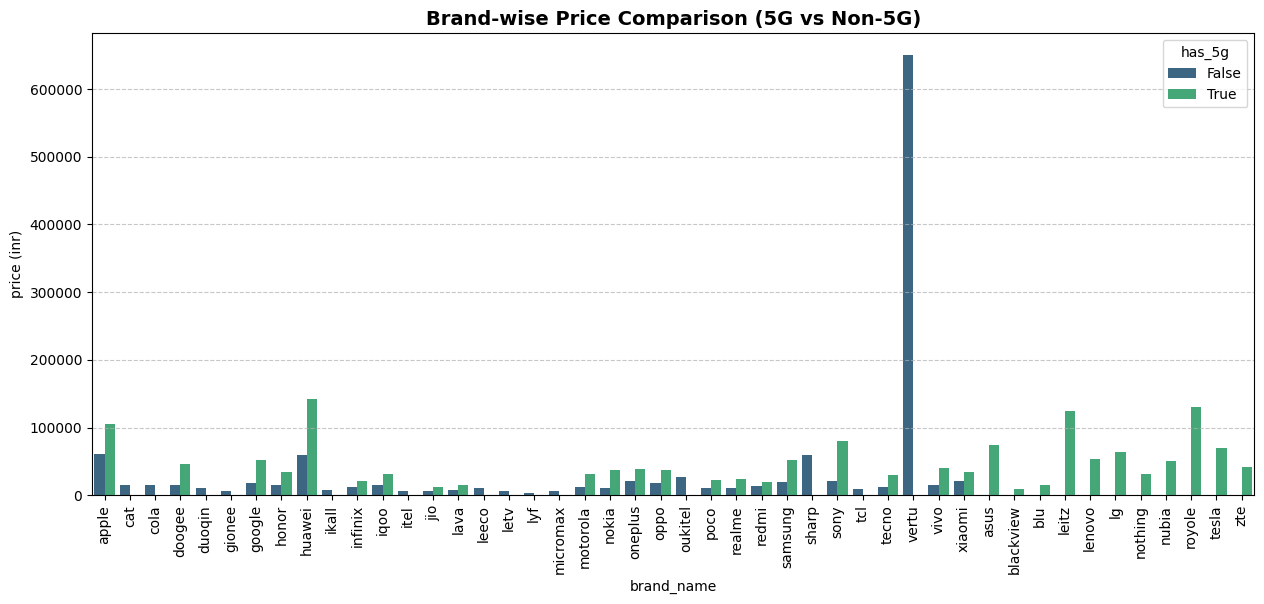

In [223]:
plt.figure(figsize=(15, 6))
sns.barplot(data=temp_df, x='brand_name', y='price (inr)', hue='has_5g', palette="viridis")
plt.xticks(rotation=90)
plt.title("Brand-wise Price Comparison (5G vs Non-5G)", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)


#conclusion
- 5G smartphones are generally more expensive than non-5G models across most brands.

- outlier as per price --Certain brands, like Vertu and Huawei, have extreme price variations, making it harder to observe clear trends.

- Apple, Samsung, and OnePlus show a consistent price jump for 5G models

#price vs processor_brand

In [224]:
smartphones.groupby('processor_brand')['price (inr)'].mean().sort_values(ascending=False)

,price (inr)
processor_brand,
bionic,103171.358974
kirin,95699.857143
apple,71999.000000
google,55505.333333
a13,53157.600000
fusion,52990.000000
snapdragon,40330.148883
exynos,38246.653061
dimensity,26163.666667


In [225]:
x=smartphones[smartphones['processor_brand']=='samsung']
smartphones.loc[x.index,'processor_brand']='exynos'

In [226]:
x=smartphones[smartphones['processor_brand'].str.contains('sanpdragon',na=False)]['processor_brand']
smartphones.loc[x.index,'processor_brand']='snapdragon'

In [227]:
x=smartphones[smartphones['processor_brand']=='google']
smartphones.loc[x.index,'processor_brand']='tensor'

In [228]:
smartphones['processor_brand'] = smartphones['processor_brand'].replace(
    {"bionic": "apple bionic", "a13": "apple bionic", "fusion": "apple bionic"})

In [229]:
smartphones['processor_brand'] = smartphones['processor_brand'].replace(
    {"mediatek":"mediatek dimensity","dimensity": "mediatek dimensity"}
)


In [230]:
x=smartphones[smartphones['processor_brand']=='sc9863a']
smartphones.loc[x.index,'processor_brand']='unisoc'

In [231]:
x=smartphones[smartphones['processor_brand']=='spreadtrum']
smartphones.loc[x.index,'processor_brand']='unisoc'

In [232]:
temp_df=smartphones[smartphones['processor_brand'].isnull()]

In [233]:
temp_df

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
41,xiaomi,Xiaomi Redmi Note 11 Pro Plus 5G,19999,83.000000,True,False,True,Snapdragon 695,NaN,Octa Core,2.2,6.0,128.0,5000.0,67,6.67,1080 x 2400,120,3,1,108.0,16.0,android,1 TB
118,tesla,Tesla Pi Phone,69999,83.000000,True,True,False,NaN,NaN,Octa Core,NaN,16.0,512.0,5000.0,120,6.73,1080 x 2448,165,3,1,50.0,32.0,android,0
135,xiaomi,Xiaomi Redmi Note 11 Pro Plus 5G (8GB RAM + 25...,22999,87.000000,True,False,True,Snapdragon 695,NaN,Octa Core,2.2,8.0,256.0,5000.0,67,6.67,1080 x 2400,120,3,1,108.0,16.0,android,1 TB
143,jio,Jio Phone 3,4499,78.258248,False,False,False,NaN,NaN,Quad Core,1.4,2.0,64.0,2800.0,-1,6.58,720 x 1280,60,1,1,5.0,2.0,android,128 GB
156,oppo,OPPO F21 Pro 5G,25969,82.000000,True,False,False,Snapdragon 695,NaN,Octa Core,2.2,8.0,128.0,4500.0,33,6.43,1080 x 2400,60,3,1,64.0,16.0,android,1 TB
187,ikall,iKall Z19 Pro,8099,60.000000,False,False,False,NaN,NaN,Quad Core,1.6,4.0,64.0,5000.0,-1,6.50,720 x 1600,60,1,1,13.0,8.0,android,128 GB
200,samsung,Samsung Galaxy A13,14450,75.000000,False,False,False,NaN,NaN,Octa Core,2.0,4.0,64.0,5000.0,25,6.60,1080 x 2408,60,4,1,50.0,8.0,android,1 TB
273,xiaomi,Xiaomi Redmi Note 11 Pro Plus 5G (8GB RAM + 12...,22700,86.000000,True,False,True,Snapdragon 695,NaN,Octa Core,2.2,8.0,128.0,5000.0,67,6.67,1080 x 2400,120,3,1,108.0,16.0,android,1 TB
307,samsung,Samsung Galaxy A13 (4GB RAM + 128GB),14999,75.000000,False,False,False,NaN,NaN,Octa Core,2.0,4.0,128.0,5000.0,25,6.60,1080 x 2408,60,4,1,50.0,8.0,android,1 TB
313,itel,itel S16 Pro,6990,78.258248,False,False,False,NaN,NaN,Quad Core,1.3,2.0,32.0,4000.0,-1,6.60,1600 x 720,60,3,1,8.0,8.0,android,32 GB


In [234]:
x=temp_df[temp_df['processor_name'].str.contains('Snapdragon',na=False)]
smartphones.loc[x.index,'processor_brand']='snapdragon'

In [235]:
smartphones[smartphones['processor_brand'].isnull()]

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
118,tesla,Tesla Pi Phone,69999,83.000000,True,True,False,NaN,NaN,Octa Core,NaN,16.0,512.0,5000.0,120,6.73,1080 x 2448,165,3,1,50.0,32.0,android,0
143,jio,Jio Phone 3,4499,78.258248,False,False,False,NaN,NaN,Quad Core,1.4,2.0,64.0,2800.0,-1,6.58,720 x 1280,60,1,1,5.0,2.0,android,128 GB
187,ikall,iKall Z19 Pro,8099,60.000000,False,False,False,NaN,NaN,Quad Core,1.6,4.0,64.0,5000.0,-1,6.50,720 x 1600,60,1,1,13.0,8.0,android,128 GB
200,samsung,Samsung Galaxy A13,14450,75.000000,False,False,False,NaN,NaN,Octa Core,2.0,4.0,64.0,5000.0,25,6.60,1080 x 2408,60,4,1,50.0,8.0,android,1 TB
307,samsung,Samsung Galaxy A13 (4GB RAM + 128GB),14999,75.000000,False,False,False,NaN,NaN,Octa Core,2.0,4.0,128.0,5000.0,25,6.60,1080 x 2408,60,4,1,50.0,8.0,android,1 TB
313,itel,itel S16 Pro,6990,78.258248,False,False,False,NaN,NaN,Quad Core,1.3,2.0,32.0,4000.0,-1,6.60,1600 x 720,60,3,1,8.0,8.0,android,32 GB
490,samsung,Samsung Galaxy A15,15990,63.000000,False,False,False,NaN,NaN,Octa Core,NaN,6.0,64.0,5000.0,0,6.50,720 x 1600,60,3,1,48.0,8.0,android,1 TB
523,samsung,Samsung Galaxy F14,14990,67.000000,False,True,False,NaN,NaN,Octa Core,NaN,4.0,64.0,5000.0,25,6.62,2408 x 1080,60,3,1,50.0,16.0,android,1 TB
575,samsung,Samsung Galaxy A13 (6GB RAM + 128GB),16499,78.000000,False,False,False,NaN,NaN,Octa Core,2.0,6.0,128.0,5000.0,25,6.60,1080 x 2408,60,4,1,50.0,8.0,android,1 TB
733,ikall,iKall Z19,7999,61.000000,False,False,False,NaN,NaN,Quad Core,1.6,4.0,32.0,5000.0,-1,6.50,720 x 1600,60,1,1,20.0,13.0,android,128 GB


In [236]:
smartphones.loc[smartphones[smartphones['model'].str.contains('Samsung Galaxy A13')].index,'processor_brand']='mediatek dimensity'

In [237]:
smartphones['processor_brand'].isnull().sum()

np.int64(17)

In [238]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy A11'].index,'processor_brand']='snapdragon'

In [239]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy F14'].index,'processor_brand']='snapdragon'

In [240]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy A05'].index,'processor_brand']='helio'

In [241]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy M35'].index,'processor_brand']='exynos'

In [242]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy M52s 5G'].index,'processor_brand']='snapdragon'

In [243]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy M51s 5G'].index,'processor_brand']='snapdragon'

In [244]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy S23 FE 5G'].index,'processor_brand']='exynos'

In [245]:
smartphones.loc[smartphones[smartphones['model']=='Samsung Galaxy A15'].index,'processor_brand']='helio'

In [246]:
smartphones.loc[smartphones[smartphones['model']=='Tesla Pi Phone'].index,'processor_brand']='snapdragon'

In [247]:
smartphones.loc[smartphones[smartphones['model']=='Tecno Spark Go 2022'].index,'processor_brand']='unisoc'

In [248]:
smartphones.loc[smartphones[smartphones['model']=='Huawei Nova Y61'].index,'processor_brand']='kirin'

In [249]:
smartphones.loc[smartphones[smartphones['model']=='Jio Phone 3'].index,'processor_brand']='mediatek dimensity'

In [250]:
smartphones.loc[smartphones[smartphones['model'].str.contains('itel')].index,'processor_brand'] = 'unisoc'

In [251]:
smartphones.loc[smartphones[smartphones['model'].str.contains('iKall')].index,'processor_brand'] = 'snapdragon'

<ipython-input-252-ed67d97a8c2a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smartphones, x='processor_brand', y='price (inr)',palette='viridis')
<ipython-input-252-ed67d97a8c2a>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1,1), title="Brand", fontsize=10)


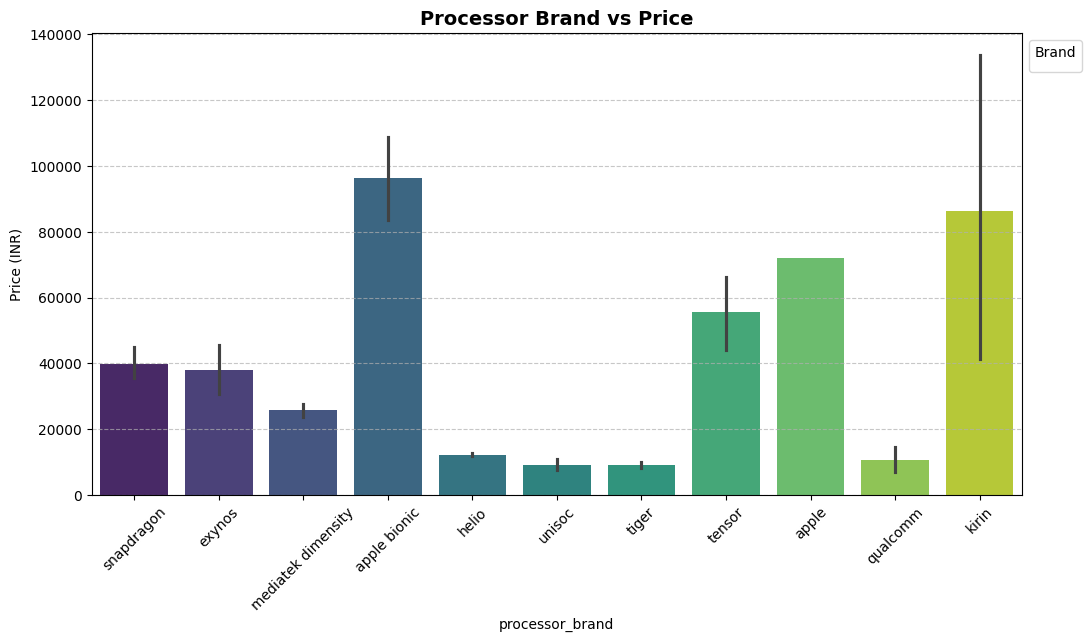

In [252]:
plt.figure(figsize=(12, 6))

sns.barplot(data=smartphones, x='processor_brand', y='price (inr)',palette='viridis')
plt.xticks(rotation=45)
plt.title("Processor Brand vs Price", fontsize=14, fontweight='bold')
plt.ylabel("Price (INR)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1,1), title="Brand", fontsize=10)

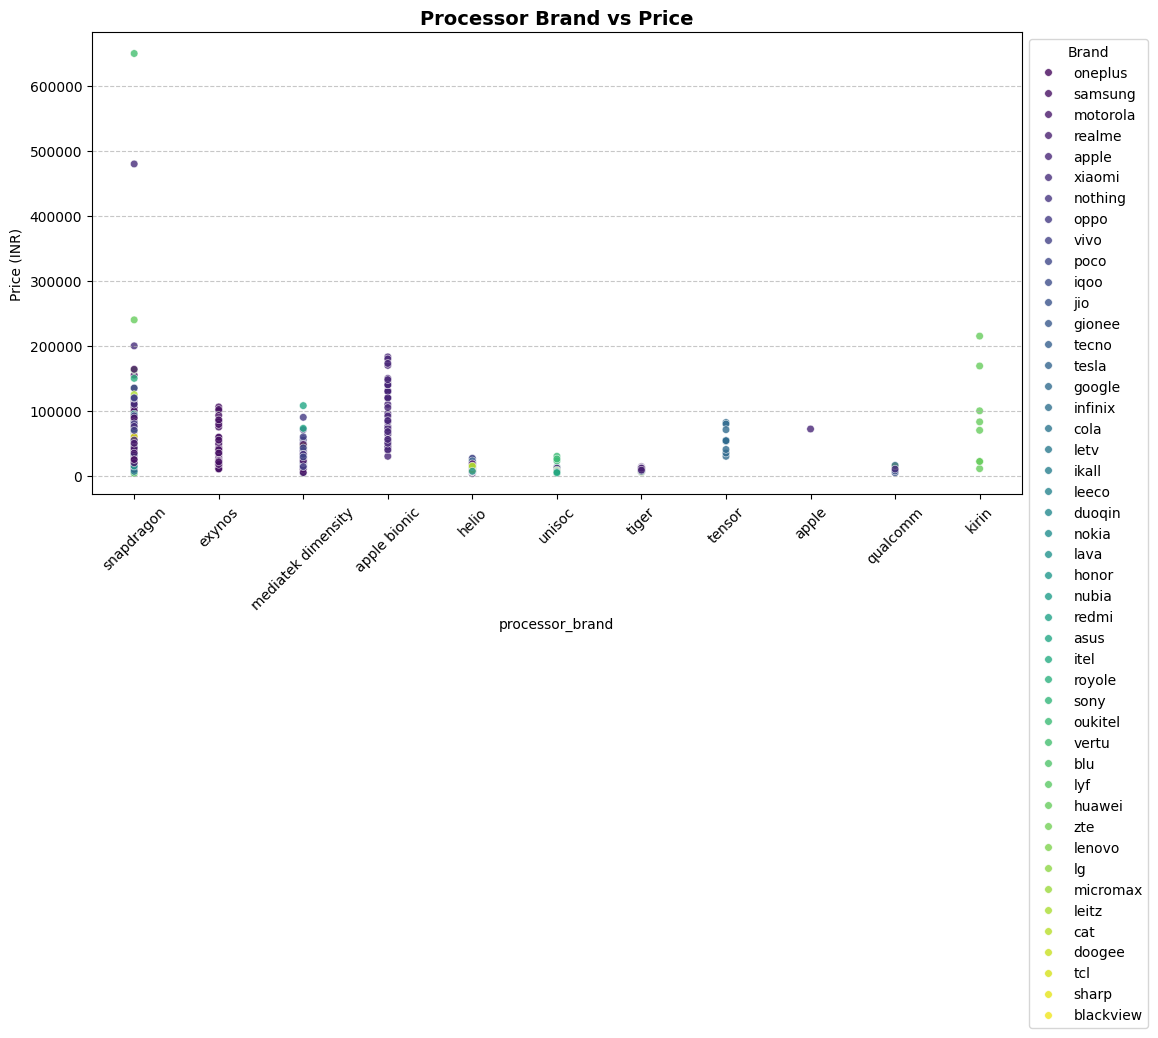

In [253]:
plt.figure(figsize=(12, 6))

sns.scatterplot(data=smartphones, x='processor_brand', y='price (inr)',palette='viridis',hue='brand_name',alpha=0.8,s=30)
plt.xticks(rotation=45)
plt.title("Processor Brand vs Price", fontsize=14, fontweight='bold')
plt.ylabel("Price (INR)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1,1), title="Brand", fontsize=10)


In [254]:
smartphones['num_cores'].value_counts()

,count
num_cores,
Octa Core,899
Hexa Core,39
Quad Core,36


In [255]:
smartphones['num_cores'].isnull().sum()

np.int64(6)

In [256]:
smartphones[smartphones['num_cores'].isnull()]

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
152,apple,Apple iPhone 15 Pro Max,142990,79.0,True,True,False,Bionic A16,apple bionic,NaN,NaN,8.0,256.0,4352.0,25,6.68,1284 x 2778,120,3,1,50.0,12.0,ios,0
262,apple,Apple iPhone XR2,71999,60.0,False,True,False,Apple A13,apple,NaN,NaN,4.0,64.0,3060.0,0,6.10,828 x 1792,60,2,1,12.0,7.0,ios,0
280,apple,Apple iPhone 14 Mini,69990,70.0,False,True,False,Bionic A16,apple bionic,NaN,NaN,6.0,128.0,3500.0,0,5.42,1080 x 2340,60,2,1,12.0,12.0,ios,0
425,nokia,Nokia X50 5G,34999,76.0,True,False,False,Snapdragon 775,snapdragon,NaN,NaN,6.0,64.0,6000.0,33,6.81,1080 x 2400,60,4,1,108.0,32.0,android,Not Specified
444,apple,Apple iPhone 15 Pro,130990,75.0,True,True,False,Bionic A16,apple bionic,NaN,NaN,8.0,128.0,3279.0,-1,6.06,1170 x 2532,120,3,1,50.0,12.0,ios,0
706,apple,Apple iPhone 15,82990,72.0,False,True,False,Bionic A16,apple bionic,NaN,NaN,6.0,128.0,3285.0,0,6.06,1170 x 2532,60,2,1,50.0,13.0,ios,0


In [257]:
smartphones.loc[smartphones[smartphones['model']=='Nokia X50 5G'].index,'num_cores']='Octa Core'

In [258]:
smartphones.loc[smartphones[smartphones['num_cores'].isnull()].index,'num_cores']='Hexa Core'

<ipython-input-259-f297b0582cdb>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smartphones,x='num_cores',y='price (inr)',palette='viridis',estimator=np.median)


<Axes: xlabel='num_cores', ylabel='price (inr)'>

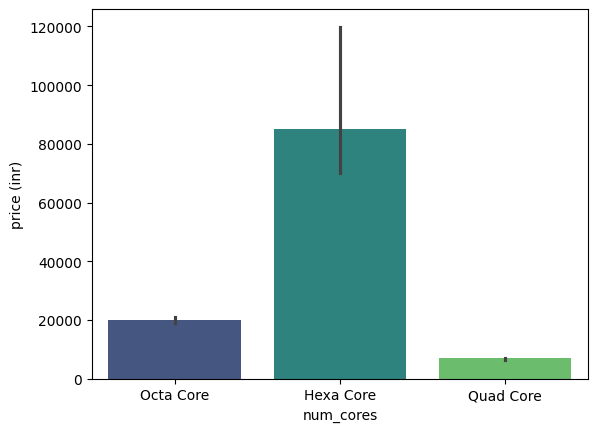

In [259]:
sns.barplot(data=smartphones,x='num_cores',y='price (inr)',palette='viridis',estimator=np.median)

# conclusion
- Apple Bionic and Kirin processors tend to have the highest average prices
- Snapdragon and Exynos processors show a wide spread of prices, indicating they are used in both budget and flagship smartphones.
- Helio, Unisoc, and Tiger are mainly used in budget devices, with the lowest price range.
- apples has hexa core thats y avg price are high .


In [260]:
smartphones.head(3)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.70,1440 x 3216,120,3,1,50.0,16.0,android,0
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,Snapdragon 695,snapdragon,Octa Core,2.2,6.0,128.0,5000.0,33,6.59,1080 x 2412,120,3,1,64.0,16.0,android,1 TB
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,Exynos 1330,exynos,Octa Core,2.4,4.0,64.0,5000.0,15,6.60,1080 x 2408,90,3,1,50.0,13.0,android,1 TB


#storage vs price

In [261]:
smartphones['ram_capacity (gb)'].isnull().sum()

np.int64(0)

<ipython-input-262-ea843cb9d082>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smartphones, x='ram_capacity (gb)', y='price (inr)',palette='viridis')


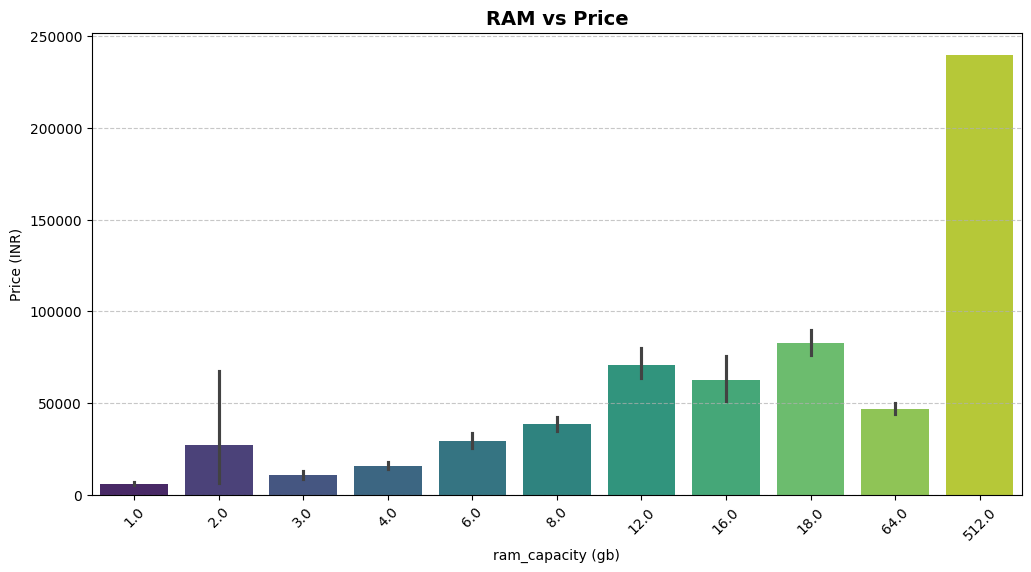

In [262]:
plt.figure(figsize=(12, 6))

sns.barplot(data=smartphones, x='ram_capacity (gb)', y='price (inr)',palette='viridis')
plt.xticks(rotation=45)
plt.title("RAM vs Price", fontsize=14, fontweight='bold')
plt.ylabel("Price (INR)")
plt.grid(axis='y', linestyle='--', alpha=0.7)



In [263]:
correlation_data = smartphones[["price (inr)", "ram_capacity (gb)", "rom_capacity (gb)"]].corr()
correlation_data

,price (inr),ram_capacity (gb),rom_capacity (gb)
price (inr),1.000000,0.228309,0.466788
ram_capacity (gb),0.228309,1.000000,0.714501
rom_capacity (gb),0.466788,0.714501,1.000000


<ipython-input-264-67c184a58f36>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smartphones, x='rom_capacity (gb)', y='price (inr)',palette='viridis')


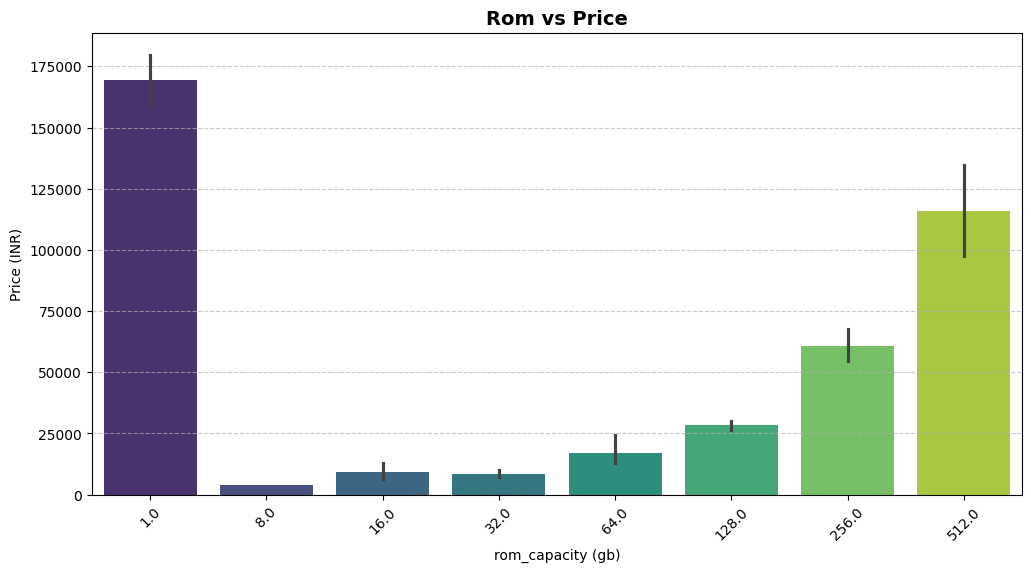

In [264]:
plt.figure(figsize=(12, 6))

sns.barplot(data=smartphones, x='rom_capacity (gb)', y='price (inr)',palette='viridis')
plt.xticks(rotation=45)
plt.title("Rom vs Price", fontsize=14, fontweight='bold')
plt.ylabel("Price (INR)")
plt.grid(axis='y', linestyle='--', alpha=0.7)


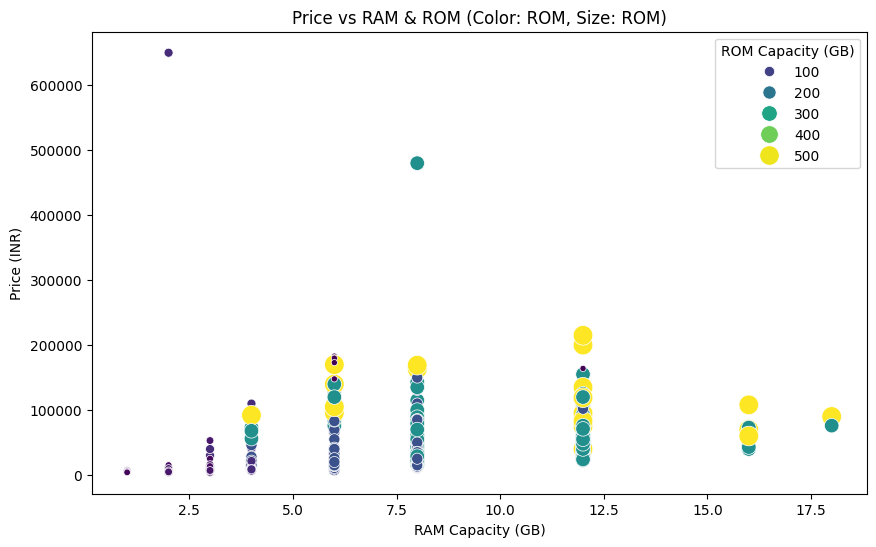

In [265]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smartphones, x="ram_capacity (gb)", y="price (inr)", hue="rom_capacity (gb)", palette="viridis", size="rom_capacity (gb)", sizes=(20, 200))

plt.title("Price vs RAM & ROM (Color: ROM, Size: ROM)")
plt.xlabel("RAM Capacity (GB)")
plt.ylabel("Price (INR)")
plt.legend(title="ROM Capacity (GB)")
plt.show()

#conclusion

- Both ROM and RAM impact the price significantly.

- ROM has a more stable effect on price, while RAM shows some outliers (some models are unusually expensive).

- For a budget-friendly phone, an 8GB RAM & 128GB ROM combination would be a good balance.

#camera

<ipython-input-266-5ecd7d66b0c4>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smartphones, x="rear_camera (mp)", y="price (inr)", palette="viridis")


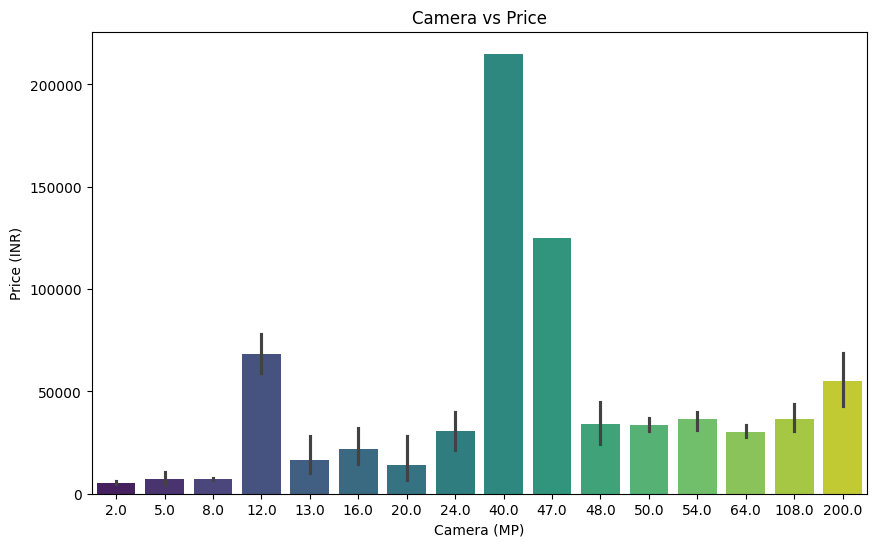

In [266]:
plt.figure(figsize=(10, 6))
sns.barplot(data=smartphones, x="rear_camera (mp)", y="price (inr)", palette="viridis")

plt.title("Camera vs Price")
plt.xlabel("Camera (MP)")
plt.ylabel("Price (INR)")
plt.show()

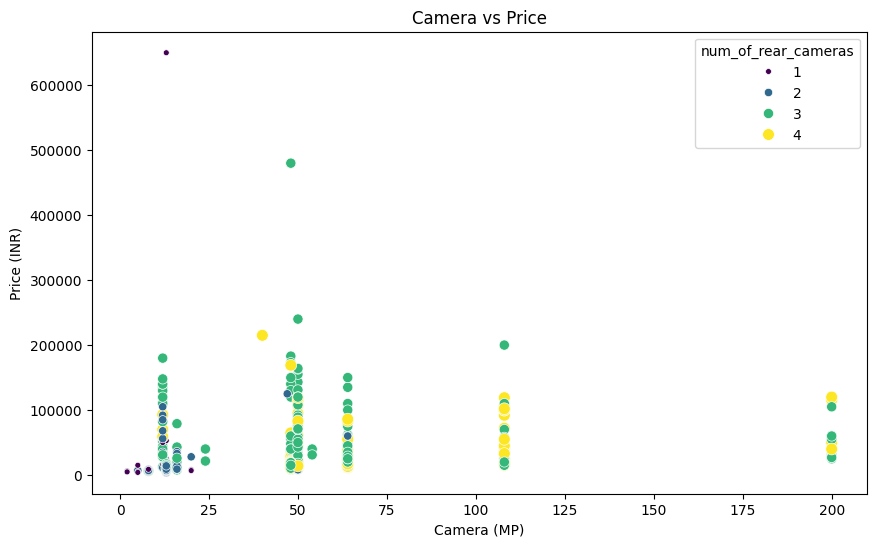

In [267]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smartphones, x="rear_camera (mp)", y="price (inr)",hue='num_of_rear_cameras', palette="viridis",size='num_of_rear_cameras')

plt.title("Camera vs Price")
plt.xlabel("Camera (MP)")
plt.ylabel("Price (INR)")
plt.show()


In [268]:
smartphones.head(1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.7,1440 x 3216,120,3,1,50.0,16.0,android,0


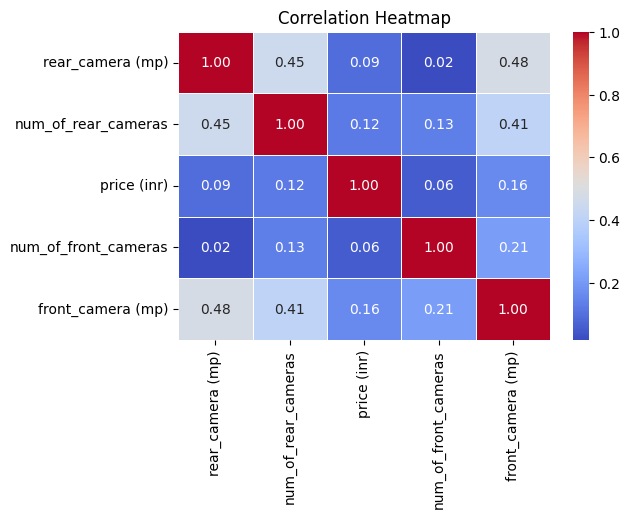

In [269]:
correlation_matrix = smartphones[['rear_camera (mp)', 'num_of_rear_cameras', 'price (inr)','num_of_front_cameras','front_camera (mp)']].corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Titles and labels
plt.title("Correlation Heatmap")
plt.show()

In [270]:
def conver_resolution(resolution):
  width,height=map(int,resolution.replace("\u2009", "").split("x"))
  return width*height
total_pixel=smartphones['resolution (pixels)'].apply(conver_resolution)
smartphones.insert(22,'total_pixel',total_pixel)

In [271]:
smartphones.head(4)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),total_pixel,os,extended_memory
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,Snapdragon 8 Gen2,snapdragon,Octa Core,3.2,12.0,256.0,5000.0,100,6.70,1440 x 3216,120,3,1,50.0,16.0,4631040,android,0
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,Snapdragon 695,snapdragon,Octa Core,2.2,6.0,128.0,5000.0,33,6.59,1080 x 2412,120,3,1,64.0,16.0,2604960,android,1 TB
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,Exynos 1330,exynos,Octa Core,2.4,4.0,64.0,5000.0,15,6.60,1080 x 2408,90,3,1,50.0,13.0,2600640,android,1 TB
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,Snapdragon 695,snapdragon,Octa Core,2.2,6.0,128.0,5000.0,0,6.55,1080 x 2400,120,3,1,50.0,16.0,2592000,android,1 TB


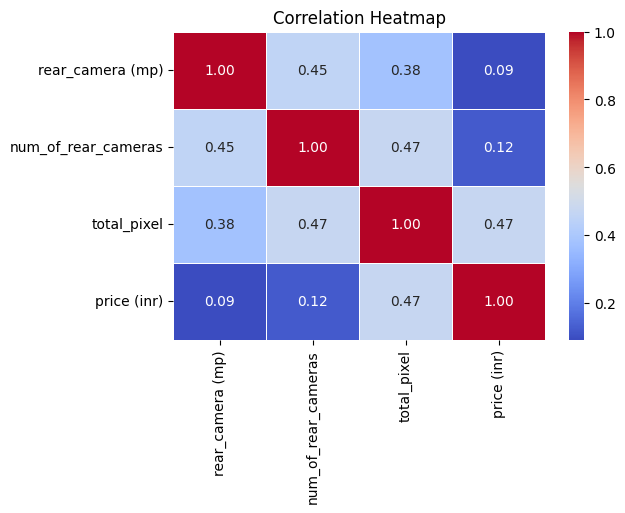

In [272]:
correlation_matrix = smartphones[['rear_camera (mp)', 'num_of_rear_cameras', 'total_pixel','price (inr)']].corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Titles and labels
plt.title("Correlation Heatmap")
plt.show()

# conclusion
-  from the scatter plot, it appears that smartphones with more rear cameras tend to have higher megapixel values for the rear camera. Additionally, the price generally increases with higher camera megapixels, though there are some exceptions.
-Rear Camera MP vs. Number of Rear Cameras: 0.454 → Moderate positive correlation, meaning smartphones with more rear cameras tend to have higher megapixels.

- Rear Camera MP vs. Price: 0.092 → Very weak positive correlation, indicating that camera megapixels alone do not strongly influence price.

- Number of Rear Cameras vs. Price: 0.123 → Weak positive correlation, suggesting that having more rear cameras has a small impact on price.
same for front
- Total Pixels vs. Price: 0.47 → Moderate positive correlation, meaning higher resolution screens tend to be in more expensive phones

<ipython-input-273-04538a439cd1>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smartphones, x='os', y="price (inr)", palette="viridis")


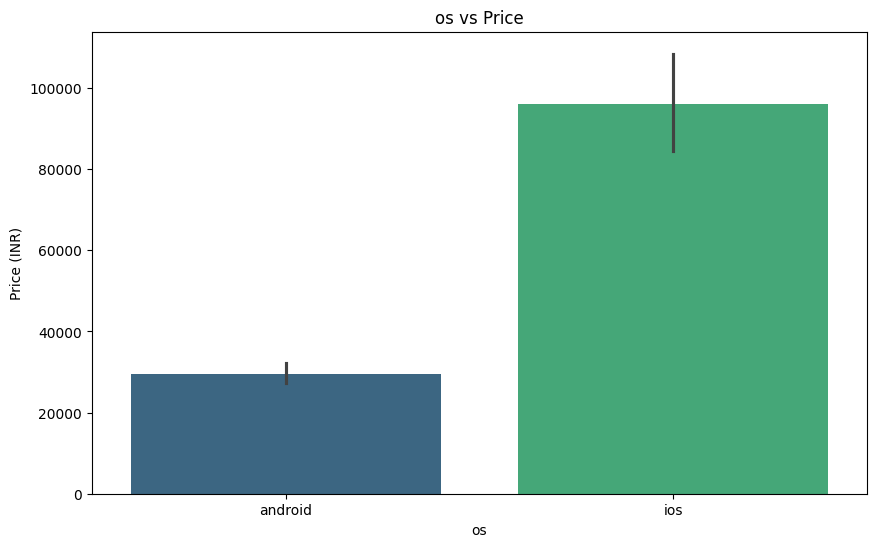

In [273]:
plt.figure(figsize=(10, 6))
sns.barplot(data=smartphones, x='os', y="price (inr)", palette="viridis")

plt.title("os vs Price")
plt.xlabel("os")
plt.ylabel("Price (INR)")
plt.show()

#conclusion
as we all know ios are heigher in pice

# battery


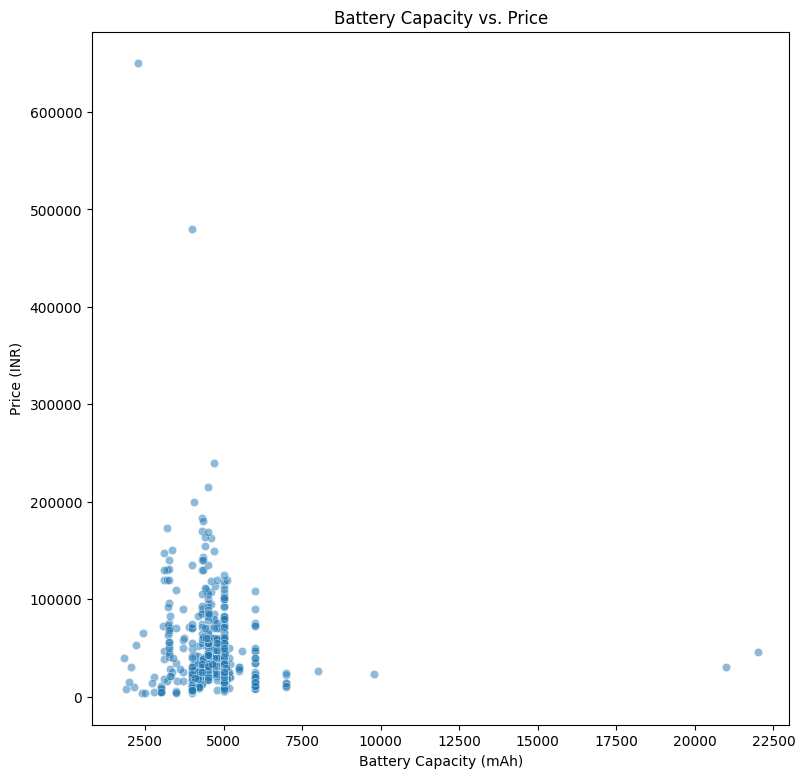

In [274]:
plt.figure(figsize=(9, 9))
sns.scatterplot(data=smartphones, x="battery_capacity (mah)", y="price (inr)", alpha=0.5)


plt.title("Battery Capacity vs. Price")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Price (INR)")
plt.show()

# **Flagship vs. Mid-Range vs. Budget Categorization**
- **Flagship – High-end processors**

- **Mid-Range –**

- **Budget – Entry-level**

In [275]:
def categorize_price(price):
    if price <= 25000:
        return 'Budget'
    elif 25000 < price <= 50000:
        return 'Mid-Range'
    elif 50000 < price <= 100000:
        return 'Premium'
    elif 100000 < price <= 200000:
        return 'Flagship'
    else:
        return 'ultra Luxurious'

In [276]:
budget_categorisation=smartphones['price (inr)'].apply(categorize_price)
smartphones.insert(25,'budget_categorisation',budget_categorisation)

In [277]:
smartphones.value_counts('budget_categorisation')

,count
budget_categorisation,
Budget,605
Mid-Range,214
Premium,113
Flagship,44
ultra Luxurious,4


In [278]:
smartphones.drop('processor_name',axis=1)

,brand_name,model,price (inr),rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,speed (ghz),ram_capacity (gb),rom_capacity (gb),battery_capacity (mah),fast_charging (w),screen_size (inches),resolution (pixels),refresh_rate (hz),num_of_rear_cameras,num_of_front_cameras,rear_camera (mp),front_camera (mp),total_pixel,os,extended_memory,budget_categorisation
0,oneplus,OnePlus 11 5G,54999,89.000000,True,True,False,snapdragon,Octa Core,3.20,12.0,256.0,5000.0,100,6.70,1440 x 3216,120,3,1,50.0,16.0,4631040,android,0,Premium
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.000000,True,False,False,snapdragon,Octa Core,2.20,6.0,128.0,5000.0,33,6.59,1080 x 2412,120,3,1,64.0,16.0,2604960,android,1 TB,Budget
2,samsung,Samsung Galaxy A14 5G,16499,75.000000,True,False,False,exynos,Octa Core,2.40,4.0,64.0,5000.0,15,6.60,1080 x 2408,90,3,1,50.0,13.0,2600640,android,1 TB,Budget
3,motorola,Motorola Moto G62 5G,14999,81.000000,True,False,False,snapdragon,Octa Core,2.20,6.0,128.0,5000.0,0,6.55,1080 x 2400,120,3,1,50.0,16.0,2592000,android,1 TB,Budget
4,realme,Realme 10 Pro Plus,24999,82.000000,True,False,False,mediatek dimensity,Octa Core,2.60,6.0,128.0,5000.0,67,6.70,1080 x 2412,120,3,1,108.0,16.0,2604960,android,0,Budget
5,samsung,Samsung Galaxy F23 5G (6GB RAM + 128GB),16999,80.000000,True,True,False,snapdragon,Octa Core,2.20,6.0,128.0,5000.0,25,6.60,1080 x 2408,120,3,1,50.0,8.0,2600640,android,1 TB,Budget
6,apple,Apple iPhone 14,65999,81.000000,True,True,False,apple bionic,Hexa Core,3.22,6.0,128.0,3279.0,0,6.10,1170 x 2532,60,2,1,12.0,12.0,2962440,ios,0,Premium
7,xiaomi,Xiaomi Redmi Note 12 Pro Plus,29999,86.000000,True,False,True,mediatek dimensity,Octa Core,2.60,8.0,256.0,4980.0,120,6.67,1080 x 2400,120,3,1,200.0,16.0,2592000,android,0,Mid-Range
8,nothing,Nothing Phone 1,26749,85.000000,True,True,False,snapdragon,Octa Core,2.50,8.0,128.0,4500.0,33,6.55,1080 x 2400,120,2,1,50.0,16.0,2592000,android,Not Specified,Mid-Range
9,oneplus,OnePlus Nord 2T 5G,28999,84.000000,True,True,False,mediatek dimensity,Octa Core,3.00,8.0,128.0,4500.0,80,6.43,1080 x 2400,90,3,1,50.0,32.0,2592000,android,Not Specified,Mid-Range


In [279]:
smartphones.to_csv('smartphones.csv', index=False)
from google.colab import files
files.download('smartphones.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [280]:
smartphones.to_excel('smartphones.xlsx', index=False)
from google.colab import files
files.download('smartphones.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [281]:
smartphones.isnull().sum()

,0
brand_name,0
model,0
price (inr),0
rating,0
has_5g,0
has_nfc,0
has_ir_blaster,0
processor_name,20
processor_brand,0
num_cores,0
